---
# Shor's Factorization Algorithm
---

이 노트북에서는 Shor's Factorization Algorithm을 구현하는 실습을 진행할 것입니다. Basic Quantum operator의 리뷰부터 시작해서, 15의 소인수분해를 진행해보도록 하겠습니다.

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import QFT
import numpy as np
import math
import matplotlib.pyplot as plt
from fractions import Fraction
from collections import Counter

In [2]:
def c_amod15(a: int, power: int):
    """Controlled a^power mod 15 (N=15 전용)"""
    if a not in [2, 4, 7, 8, 11, 13]:
        raise ValueError(f"a는 2,4,7,8,11,13 중 하나여야 합니다. (현재 a={a})")
    
    U = QuantumCircuit(4, name=f"{a}^{power} mod 15")
    for _ in range(power):
        if a in [2, 13]:
            U.swap(0,1)
            U.swap(1,2)
            U.swap(2,3)
        if a in [7, 8]:
            U.swap(2,3)
            U.swap(1,2)
            U.swap(0,1)
        if a in [4, 11]:
            U.swap(1,3)
            U.swap(0,2)
        if a in [7, 11, 13]:
            for q in range(4): U.x(q)
    return U.to_gate().control()

In [3]:
def estimate_period_with_circuit_and_plot(N: int, a: int, shots: int = 100):
    """
    1. 양자 회로 생성
    2. 회로도 출력
    3. QPE 실행
    4. 히스토그램 출력
    5. 주기 r 후보 반환
    """
    print(f"\n[주기 추정] N={N}, a={a}, shots={shots}")

    # 1. gcd 체크
    g = math.gcd(a, N)
    if g != 1:
        print(f"gcd({a},{N}) = {g} ≠ 1 → 인수 발견!")
        return None, [g, N//g], None

    # 2. 큐비트 설정
    n = 4   # 타겟 레지스터
    t = 8   # 카운팅 레지스터

    qc = QuantumCircuit(t + n, t)

    # Hadamard + |1>
    for q in range(t): qc.h(q)
    qc.x(t)

    # Controlled U^{2^k}
    for q in range(t):
        qc.append(c_amod15(a, 2**q), [q] + [t + i for i in range(n)])

    # Inverse QFT
    qc.append(QFT(t, inverse=True), range(t))

    # 측정
    qc.measure(range(t), range(t))

    # 양자 회로도 출력
    print("양자 회로도:")
    display(qc.draw(fold=25))  # fold로 가로 길이 조정

    # 실행
    backend = AerSimulator()
    job = backend.run(transpile(qc, backend), shots=shots)
    counts = job.result().get_counts()

    # 히스토그램 출력
    print("측정 결과 히스토그램:")
    display(plot_histogram(counts, title=f"QPE Results (a={a}, N={N})"))

    # 상위 3개 결과 분석
    top3 = Counter(counts).most_common(3)
    print("상위 3개 측정값:")
    candidates = set()
    for bits, cnt in top3:
        val = int(bits, 2)
        phase = val / (2**t)
        print(f"  {bits} ({cnt}회) → 위상 = {phase:.5f}")
        if val == 0: continue
        frac = Fraction(phase).limit_denominator(N)
        r = frac.denominator
        if r > 1:
            candidates.add(r)

    if not candidates:
        print("유효한 r을 찾지 못했습니다.")
        return None, None, qc

    print(f"후보 주기 r = {sorted(candidates)}")
    return list(candidates), None, qc

In [4]:
def compute_factors(N: int, a: int, r: int):
    if r % 2 != 0:
        print(f"r={r}은 홀수 → 실패")
        return None

    exp = pow(a, r//2, N)
    f1 = math.gcd(exp - 1, N)
    f2 = math.gcd(exp + 1, N)

    if 1 < f1 < N and 1 < f2 < N and f1 * f2 == N:
        return [f1, f2]
    else:
        print(f"trivial 인수: [{f1}, {f2}] → 실패")
        return None

In [5]:
def run_shor_full_visual(N: int, a: int, shots: int = 100):
    print(f"\n{'='*80}")
    print(f"Shor's Algorithm 실행: N = {N}, a = {a}")
    print(f"{'='*80}")

    # 1. 주기 추정 + 시각화
    r_list, factors, circuit = estimate_period_with_circuit_and_plot(N, a, shots=shots)

    # 2. gcd 성공?
    if factors:
        print(f"성공! {N} = {factors[0]} × {factors[1]}")
        return factors, circuit

    # 3. QPE 실패?
    if not r_list:
        print("실패: 주기 추정 불가")
        return None, circuit

    # 4. 각 r로 인수 계산
    for r in r_list:
        print(f"\n→ r = {r}로 인수 계산...")
        result = compute_factors(N, a, r)
        if result:
            print(f"성공! {N} = {result[0]} × {result[1]}")
            return result, circuit

    print("모든 r 실패 → 다른 a를 시도하세요.")
    return None, circuit


Shor's Algorithm 실행: N = 15, a = 7

[주기 추정] N=15, a=7, shots=100
양자 회로도:


/var/tmp/braket/ipykernel_21061/1655452103.py:32: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(t, inverse=True), range(t))


┌───┐»
 q_0: ┤ H ├»
      ├───┤»
 q_1: ┤ H ├»
      ├───┤»
 q_2: ┤ H ├»
      ├───┤»
 q_3: ┤ H ├»
      ├───┤»
 q_4: ┤ H ├»
      ├───┤»
 q_5: ┤ H ├»
      ├───┤»
 q_6: ┤ H ├»
      ├───┤»
 q_7: ┤ H ├»
      ├───┤»
 q_8: ┤ X ├»
      └───┘»
 q_9: ─────»
           »
q_10: ─────»
           »
q_11: ─────»
           »
 c: 8/═════»
           »
«                     »
« q_0: ───────■───────»
«             │       »
« q_1: ───────┼───────»
«             │       »
« q_2: ───────┼───────»
«             │       »
« q_3: ───────┼───────»
«             │       »
« q_4: ───────┼───────»
«             │       »
« q_5: ───────┼───────»
«             │       »
« q_6: ───────┼───────»
«             │       »
« q_7: ───────┼───────»
«      ┌──────┴──────┐»
« q_8: ┤0            ├»
«      │             │»
« q_9: ┤1            ├»
«      │  7^1 mod 15 │»
«q_10: ┤2            ├»
«      │             │»
«q_11: ┤3            ├»
«      └─────────────┘»
« c: 8/═══════════════»
«                     »
«                     »
« q_0: ───────────────»
«                     »
« q_1: ───────■───────»
«             │       »
« q_2: ───────┼───────»
«             │       »
« q_3: ───────┼───────»
«             │       »
« q_4: ───────┼───────»
«             │       »
« q_5: ───────┼───────»
«             │       »
« q_6: ───────┼───────»
«             │       »
« q_7: ───────┼───────»
«      ┌──────┴──────┐»
« q_8: ┤0            ├»
«      │             │»
« q_9: ┤1            ├»
«      │  7^2 mod 15 │»
«q_10: ┤2            ├»
«      │             │»
«q_11: ┤3            ├»
«      └─────────────┘»
« c: 8/═══════════════»
«                     »
«                     »
« q_0: ───────────────»
«                     »
« q_1: ───────────────»
«                     »
« q_2: ───────■───────»
«             │       »
« q_3: ───────┼───────»
«             │       »
« q_4: ───────┼───────»
«             │       »
« q_5: ───────┼───────»
«             │       »
« q_6: ───────┼───────»
«             │       »
« q_7: ───────┼───────»
«      ┌──────┴──────┐»
« q_8: ┤0            ├»
«      │             │»
« q_9: ┤1            ├»
«      │  7^4 mod 15 │»
«q_10: ┤2            ├»
«      │             │»
«q_11: ┤3            ├»
«      └─────────────┘»
« c: 8/═══════════════»
«                     »
«                     »
« q_0: ───────────────»
«                     »
« q_1: ───────────────»
«                     »
« q_2: ───────────────»
«                     »
« q_3: ───────■───────»
«             │       »
« q_4: ───────┼───────»
«             │       »
« q_5: ───────┼───────»
«             │       »
« q_6: ───────┼───────»
«             │       »
« q_7: ───────┼───────»
«      ┌──────┴──────┐»
« q_8: ┤0            ├»
«      │             │»
« q_9: ┤1            ├»
«      │  7^8 mod 15 │»
«q_10: ┤2            ├»
«      │             │»
«q_11: ┤3            ├»
«      └─────────────┘»
« c: 8/═══════════════»
«                     »
«                      »
« q_0: ────────────────»
«                      »
« q_1: ────────────────»
«                      »
« q_2: ────────────────»
«                      »
« q_3: ────────────────»
«                      »
« q_4: ───────■────────»
«             │        »
« q_5: ───────┼────────»
«             │        »
« q_6: ───────┼────────»
«             │        »
« q_7: ───────┼────────»
«      ┌──────┴───────┐»
« q_8: ┤0             ├»
«      │              │»
« q_9: ┤1             ├»
«      │  7^16 mod 15 │»
«q_10: ┤2             ├»
«      │              │»
«q_11: ┤3             ├»
«      └──────────────┘»
« c: 8/════════════════»
«                      »
«                      »
« q_0: ────────────────»
«                      »
« q_1: ────────────────»
«                      »
« q_2: ────────────────»
«                      »
« q_3: ────────────────»
«                      »
« q_4: ────────────────»
«                      »
« q_5: ───────■────────»
«             │        »
« q_6: ───────┼────────»
«             │        »
« q_7: ──────

측정 결과 히스토그램:


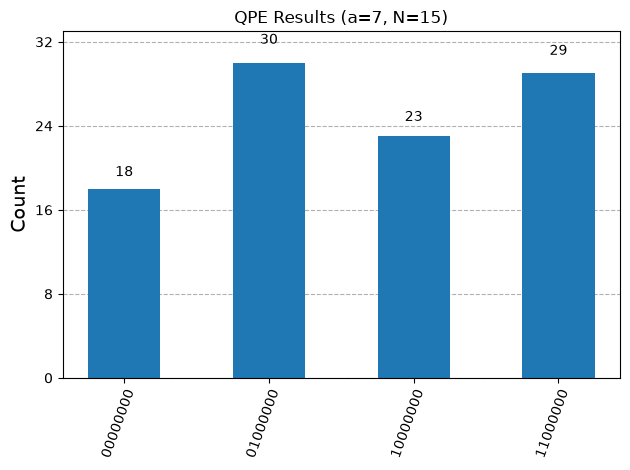

상위 3개 측정값:
  01000000 (30회) → 위상 = 0.25000
  11000000 (29회) → 위상 = 0.75000
  10000000 (23회) → 위상 = 0.50000
후보 주기 r = [2, 4]

→ r = 2로 인수 계산...
trivial 인수: [3, 1] → 실패

→ r = 4로 인수 계산...
성공! 15 = 3 × 5


In [6]:
# a=7 → r=4 → 3×5 성공!
factors, circuit = run_shor_full_visual(N=15, a=7, shots=100)